In [39]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.integrate as spi
import sympy as sp

In [61]:
# ============================
# Parameters
# ============================

year_to_seconds = 365 * 24 * 3600
### anthropogenic emissions ###
A_tot = 5000.0   # GtC, total carbon emitted
t_opt = 250.0 * year_to_seconds    # yr, t_opt for RCP8.5

t = sp.symbols("t", real=True)

# Cumulative emissions A(t)
A = A_tot * (
    1 / (1 + 2.5 * sp.exp((t_opt - t)/year_to_seconds / 50))
    - 1 / (1 + 2.5 * sp.exp(t_opt/year_to_seconds / 50))
)

# Emission rate J(t) = dA/dt
J = sp.diff(A, t)

# Fast numerical functions
A_func = sp.lambdify(t, A, "numpy")
J_func = sp.lambdify(t, J, "numpy")

### inital Temperature ###
Ts_init = 0.0      # K, initial surface temperature
Td_init = 0.0      # K, initial deep ocean temperature
lam_star = 0.75      # W m^-2 K^-1, heat transfer coefficient
lam = 1.75         # W m^-2 K^-1, climate feedback parameter
beta = 5.35         # W m^-2 K^-1, CO2 forcing parameter


### Heat capacities ###
surface_depth = 50.0
deep_depth = 3000.0
c_s = 4000.0 * surface_depth * 1000.0      # J m^-2 K^-1
c_d = 4000.0 * deep_depth * 1000.0       # J m^-2 K^-1
c_star = c_s + c_d                     # J m^-2 K^-1

### atmospheric carbon ###
k_a  = 2.12          # CO2 scaling constant
Ca_init = 600.0         # GtC, pre-industrial atmospheric carbon
P_a0 = Ca_init / k_a    # ppm, pre-industrial atmospheric CO2

etaH = 0.7         # W m^-2 K^-1, heat transfer coefficient

### land carbon ###
beta_pi = 0.4     # CO2 fertilization factor
chi     = 1.8     # scaling constant
tau_l0   = 41.0 * year_to_seconds    # yr, lifetime of land carbon
Pi_0    = 60.0/year_to_seconds    # GtC/yr, preindustrial land flux
Cl_init    = 2460.0  # GtC, preindustrial land carbon

### ocean carbon cycle ###
D     = surface_depth + deep_depth     # m, average ocean depth
delta = surface_depth / D    # fraction (mixed-layer depth / D)
gamma = 0.02 / year_to_seconds       # GtC/yr/ppm, air-sea transfer coefficient
mu_0  = 5.0 / year_to_seconds        # buffer constant (m/year)
zeta  = 6#10.5        # ratio between ocean reservoirs and atmosphere
etaC = mu_0/D       # transfer rate by total depth

# C_s0 + C_d0 = 6 * zeta * C_a0
# C_s0 / C_d0 = delta / (1 - delta)
# => solve the two simultaneous equations for C_s0, C_d0

total_sd = 6.0 * zeta * Ca_init   # GtC, total preindustrial ocean carbon
Cd_init = (1-delta) * total_sd   # GtC, preindustrial deep ocean carbon

Cs_init = total_sd - Cd_init               # GtC, preindustrial surface ocean carbon

kappa_o = 6.0 * k_a * delta   # ocean CO2 uptake constant


def climate_rhs(t, y):
    Ts, Td, Cl, Cs, Cd, Ca = y

    ### Anthropogenic emissions ###
    J = J_func(t)  # GtC/seconds

    ### Temperature evolution surface and deep ###

    forcing = beta * np.log((Ca / Ca_init) + 1.0)

    dTs = 1.0/(delta * c_star) * (-lam*Ts + forcing - (etaH + lam_star)*(Ts - Td))

    dTd = etaH*(Ts - Td)/((1-delta)*c_star)

    # ### Land carbon evolution ###
    # ### Add question: Waht Cl to use because caligraphic Cl?

    dCl = Pi_0 * (1 + beta_pi * np.log((Ca / Ca_init) + 1.0)) - ((Cl+Cl_init) / tau_l0) * chi ** (Ts / 10.0)

    # ### Surface ocean carbon evolution ###

    ko = k_a / zeta * (Cs_init / Ca_init)

    dCs = gamma * (Ca / k_a - Cs / ko) - etaC * (Cs/delta - Cd/(1-delta))

    # ### Deep ocean carbon evolution ###

    dCd = etaC * (Cs/delta - Cd/(1-delta))

    # ### Atmosphere carbon evolution ###

    dCa = J - dCs - dCl - dCd


    return [dTs, dTd, dCl, dCs, dCd, dCa]

In [71]:
#y = [Ts_init, Td_init, Cl_init, Cs_init, Cd_init, Ca_init]
y = [0,0,0,0,0,0]
t = np.arange(0, 2000, 1) * year_to_seconds # time in seconds

sol = solve_ivp(
    climate_rhs,
    (t[0], t[-1]),
    y,
    method='RK45',
    t_eval=t
)

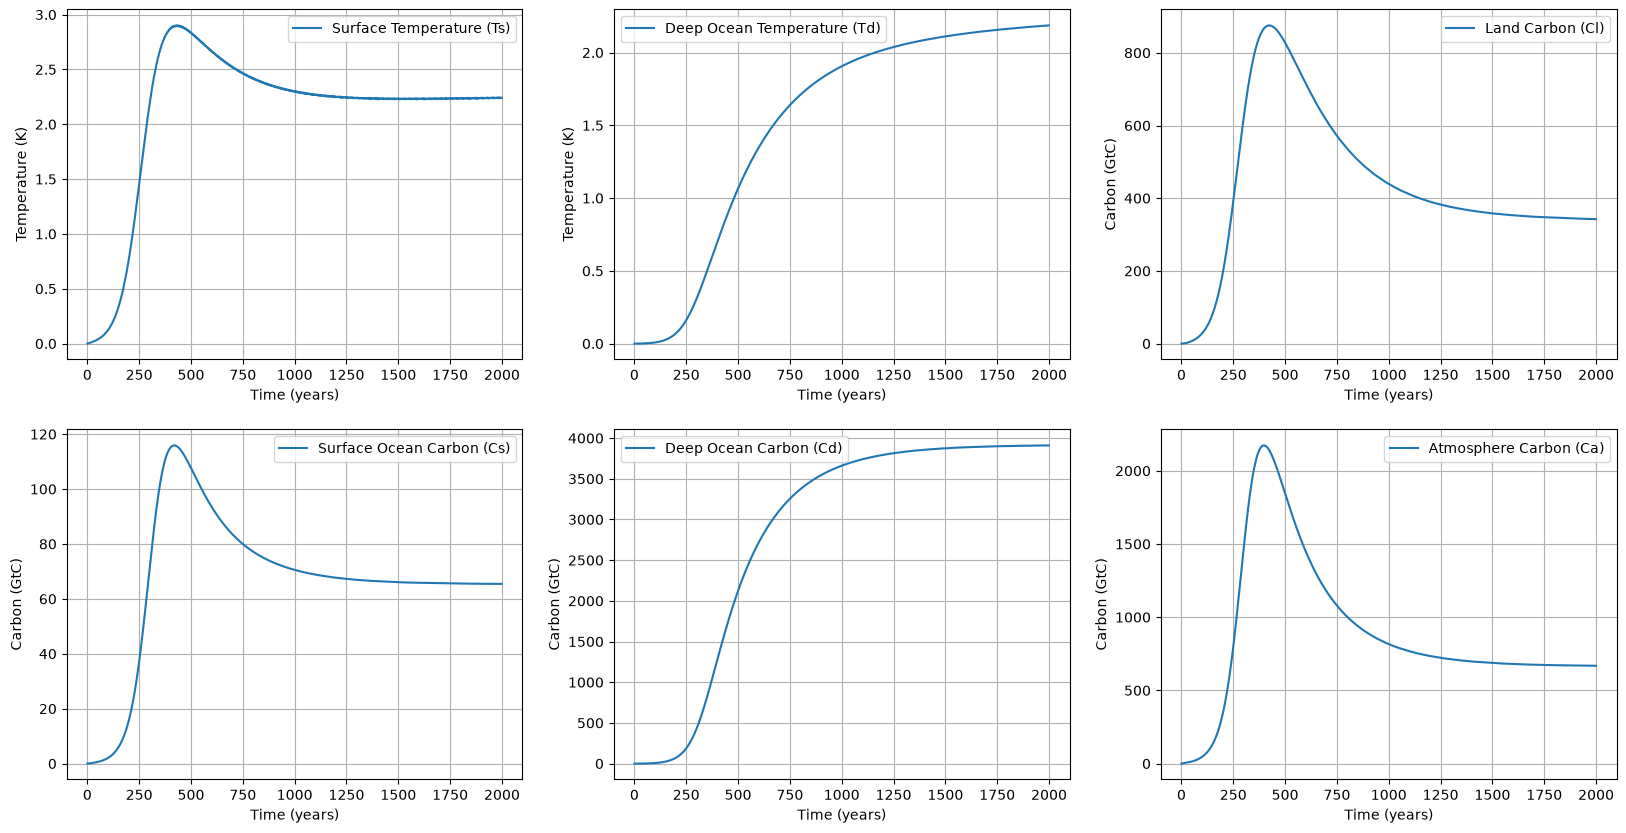

In [72]:
fig, axs = plt.subplots(2,3, figsize=(20, 10))
axs = axs.flatten()
axs[0].plot(sol.t / (86400 * 365), sol.y[0], label='Surface Temperature (Ts)')
axs[0].set_xlabel('Time (years)')
axs[0].set_ylabel('Temperature (K)')
axs[1].plot(sol.t / (86400 * 365), sol.y[1], label='Deep Ocean Temperature (Td)')
axs[1].set_xlabel('Time (years)')
axs[1].set_ylabel('Temperature (K)')
axs[2].plot(sol.t / (86400 * 365), sol.y[2], label='Land Carbon (Cl)')
axs[2].set_xlabel('Time (years)')
axs[2].set_ylabel('Carbon (GtC)')
axs[3].plot(sol.t / (86400 * 365), sol.y[3], label='Surface Ocean Carbon (Cs)')
axs[3].set_xlabel('Time (years)')
axs[3].set_ylabel('Carbon (GtC)')
axs[4].plot(sol.t / (86400 * 365), sol.y[4], label='Deep Ocean Carbon (Cd)')
axs[4].set_xlabel('Time (years)')
axs[4].set_ylabel('Carbon (GtC)')
axs[5].plot(sol.t / (86400 * 365), sol.y[5], label='Atmosphere Carbon (Ca)')
axs[5].set_xlabel('Time (years)')
axs[5].set_ylabel('Carbon (GtC)')

for ax in axs:
    ax.grid()
    ax.legend()



(0.0, 100000.0)

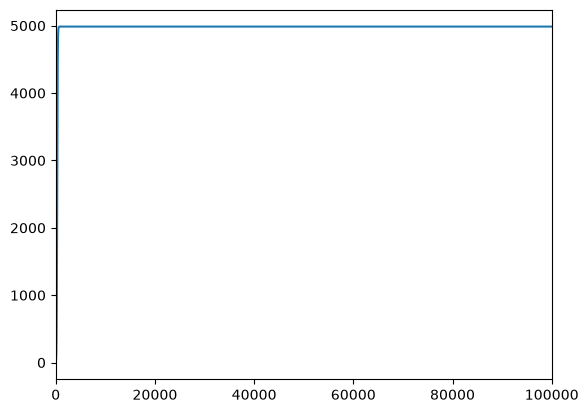

In [60]:
plt.plot(t/year_to_seconds, A_func(t))
plt.xlim(0, 100000)

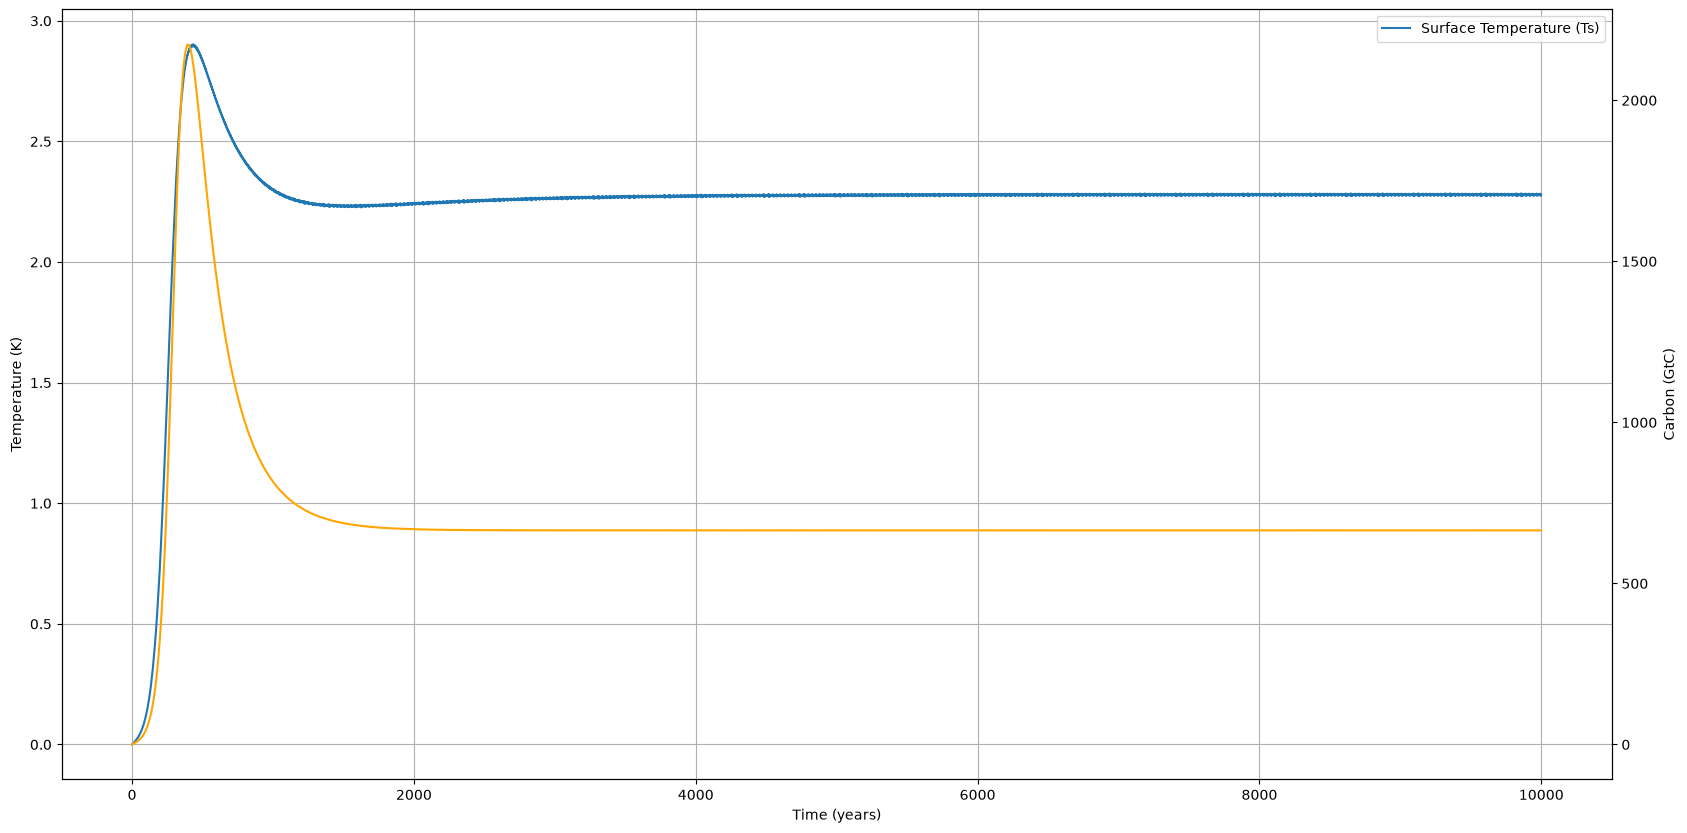

In [70]:
fig, axs = plt.subplots(1,1, figsize=(20, 10))
axs.plot(sol.t / (86400 * 365), sol.y[0], label='Surface Temperature (Ts)')
axs.set_xlabel('Time (years)')
axs.set_ylabel('Temperature (K)')
axs_ca = axs.twinx()
axs_ca.plot(sol.t / (86400 * 365), sol.y[5], label='Atmosphere Carbon (Ca)', color='orange')
axs_ca.set_xlabel('Time (years)')
axs_ca.set_ylabel('Carbon (GtC)')

axs.grid()
axs.legend()

